In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense, Dropout
import math
from sklearn.metrics import mean_squared_error
from tensorflow.keras.optimizers import Adam

In [18]:
#reading the stock market csv file
df1=pd.read_csv('/content/stock_market (1).csv')

In [19]:
#We are reversing the data frame here,for better understanding
df=df1[::-1]
l=[i for i in range(1235)]
df.insert(8,"Index",l)
df.set_index("Index",drop=True,inplace=True)

In [20]:
# Select features / target
features = ["Open", "High", "Low", "Last"]
target = ["Close"]

In [21]:
X_data = df[features].values
y_data = df[target].values

# Scale both input features and output separately
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X_data)
y_scaled = scaler_y.fit_transform(y_data)

In [22]:
def create_sequences_multivariate(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(len(X) - timesteps):
        X_seq.append(X[i:i + timesteps])   # shape -> (timesteps, 4 features)
        y_seq.append(y[i + timesteps])     # shape -> (1 output)
    return np.array(X_seq), np.array(y_seq)

timesteps = 60
X, y = create_sequences_multivariate(X_scaled, y_scaled, timesteps)

print("X shape:", X.shape)   # (samples, 60, 4)
print("y shape:", y.shape)   # (samples, 1)

X shape: (1175, 60, 4)
y shape: (1175, 1)


In [23]:
def build_model():
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(timesteps, X.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.0003), loss='mse')
    return model

In [24]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=10)
fold_losses = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    print(f"\n===== Fold {fold} =====")

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    model = build_model()
    model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=0
    )

    loss = model.evaluate(X_test, y_test, verbose=0)
    print(f"Fold {fold} Test Loss: {loss}")
    fold_losses.append(loss)

print("\nCross-validation loss:", fold_losses)
print("Average Loss:", np.mean(fold_losses))



===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Fold 1 Test Loss: 0.0010585589334368706

===== Fold 2 =====
Fold 2 Test Loss: 0.00061979447491467

===== Fold 3 =====
Fold 3 Test Loss: 0.001542571117170155

===== Fold 4 =====
Fold 4 Test Loss: 0.001157401129603386

===== Fold 5 =====
Fold 5 Test Loss: 0.00020044900884386152

===== Fold 6 =====
Fold 6 Test Loss: 0.0006306293653324246

===== Fold 7 =====
Fold 7 Test Loss: 0.00044197714305482805

===== Fold 8 =====
Fold 8 Test Loss: 0.005556638352572918

===== Fold 9 =====
Fold 9 Test Loss: 0.015461479313671589

===== Fold 10 =====
Fold 10 Test Loss: 0.005720034707337618

Cross-validation loss: [0.0010585589334368706, 0.00061979447491467, 0.001542571117170155, 0.001157401129603386, 0.00020044900884386152, 0.0006306293653324246, 0.00044197714305482805, 0.005556638352572918, 0.015461479313671589, 0.005720034707337618]
Average Loss: 0.003238953354593832


In [25]:
final_model = build_model()
final_model.fit(X, y, epochs=20, batch_size=32, verbose=1)


Epoch 1/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0607
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0065
Epoch 3/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 0.0048
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0045
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0042
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0040
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0036
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0034
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0033
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.0031
Epoch 11/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0029
Epoch 12/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0030
Epoch 13/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0033
Epoch 14/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0030
Epoch 15/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 0.0030
Epoc

In [26]:
test_size = 0.2
split = int(len(X) * (1 - test_size))

X_train_plot, X_test_plot = X[:split], X[split:]
y_train_plot, y_test_plot = y[:split], y[split:]

train_pred = final_model.predict(X_train_plot)
test_pred = final_model.predict(X_test_plot)

# inverse scale
train_pred_inv = scaler_y.inverse_transform(train_pred)
test_pred_inv  = scaler_y.inverse_transform(test_pred)
y_train_inv    = scaler_y.inverse_transform(y_train_plot)
y_test_inv     = scaler_y.inverse_transform(y_test_plot)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


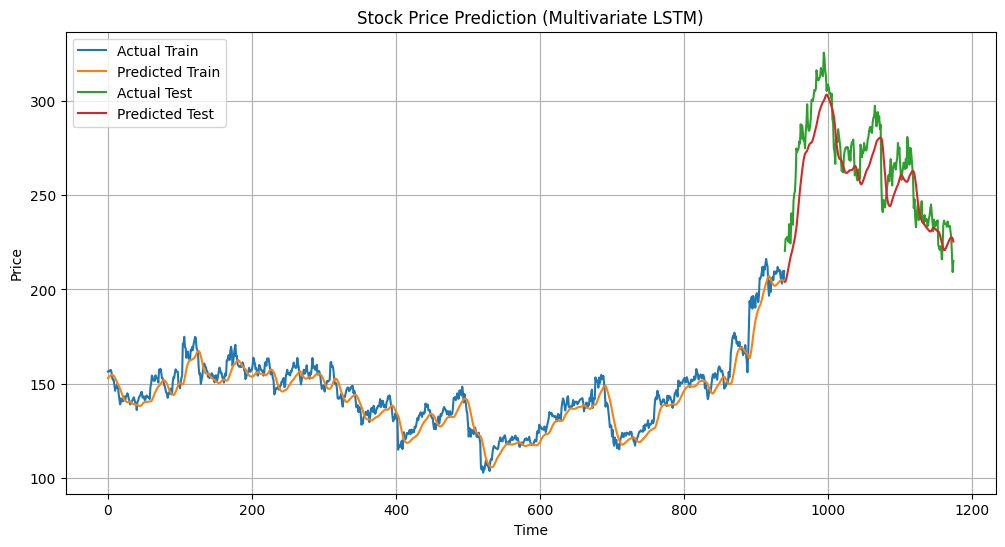

In [30]:
plt.figure(figsize=(12,6))
plt.plot(y_train_inv, label='Actual Train')
plt.plot(train_pred_inv, label='Predicted Train')
plt.plot(range(len(y_train_inv), len(y_train_inv)+len(y_test_inv)),
         y_test_inv, label='Actual Test')
plt.plot(range(len(y_train_inv), len(y_train_inv)+len(y_test_inv)),
         test_pred_inv, label='Predicted Test')

plt.title("Stock Price Prediction (Multivariate LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()


In [28]:
last_sequence = X[-1].reshape(1, timesteps, X.shape[2])
next_scaled = final_model.predict(last_sequence)
next_price = scaler_y.inverse_transform(next_scaled)

print("Next predicted close price:", next_price[0][0])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Next predicted close price: 225.44775


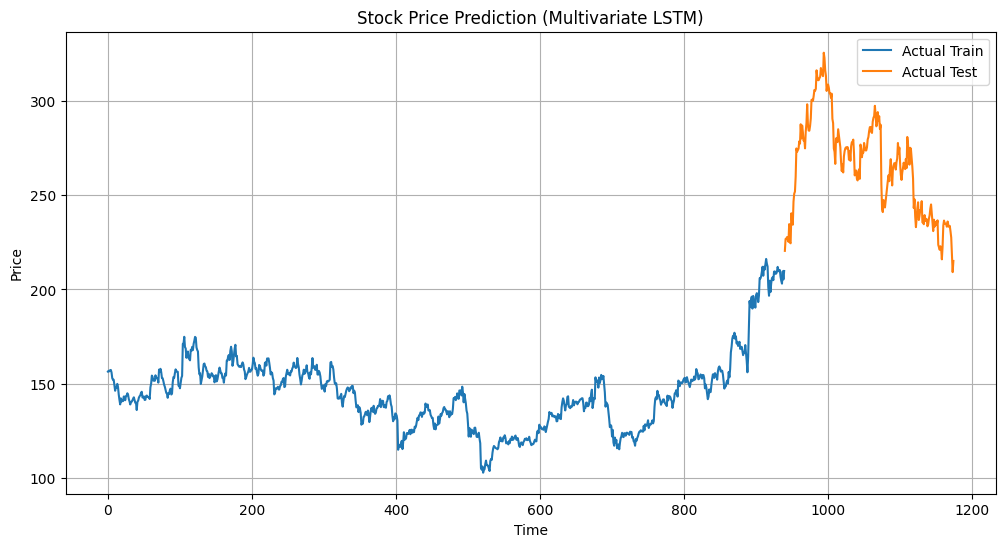

In [29]:
plt.figure(figsize=(12,6))
plt.plot(y_train_inv, label='Actual Train')
# plt.plot(train_pred_inv, label='Predicted Train')
plt.plot(range(len(y_train_inv), len(y_train_inv)+len(y_test_inv)),
         y_test_inv, label='Actual Test')
# plt.plot(range(len(y_train_inv), len(y_train_inv)+len(y_test_inv)),
#          test_pred_inv, label='Predicted Test')

plt.title("Stock Price Prediction (Multivariate LSTM)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()